In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

In [3]:
df = pd.read_csv('/Users/gametime/Downloads/Satis_verileri_guncel.csv')


In [4]:
print(df.head())

   Origin  Year  Week Component SKU  Total Demand Average Selling Price  \
0       0  2024     1      TR2299AS            15               $249.99   
1       0  2024     1      TR2430AS             9               $249.99   
2       0  2024     1      TR2445AS            26               $169.99   
3       0  2024     1      TR2525AS             6               $279.99   
4       0  2024     1      TR2550AS             9               $219.99   

   IsHoliday  IsPromotion      COG  Profit Rate  Average Rating  \
0          1            0  $112.92           25             4.4   
1          1            0   $98.96           22             4.3   
2          1            0   $98.96           25             4.4   
3          1            0  $125.50           15             4.2   
4          1            0  $130.48            7             4.2   

   Product Category Advertising Spend Competitor Price Index  
0                 0           $185.00                $195.99  
1                 0 

In [5]:
print(df.tail())

      Origin  Year  Week Component SKU  Total Demand Average Selling Price  \
2861       1  2025    39      TR2598AS             1               $184.98   
2862       1  2025    39      TR2613AS             7               $189.99   
2863       0  2025    39      TR2550AS             2               $167.98   
2864       0  2025    39        TR8864             6               $113.99   
2865       0  2025    39        TR9781             4                $87.26   

      IsHoliday  IsPromotion     COG  Profit Rate  Average Rating  \
2861          0            0  $74.06           10             4.2   
2862          0            0  $80.57           13             4.1   
2863          0            0  $98.31            7             4.2   
2864          0            0  $36.97           35             4.4   
2865          0            0  $43.28           25             4.6   

      Product Category Advertising Spend Competitor Price Index  
2861                 0           $350.00          

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2866 entries, 0 to 2865
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Origin                  2866 non-null   int64  
 1   Year                    2866 non-null   int64  
 2   Week                    2866 non-null   int64  
 3   Component SKU           2866 non-null   object 
 4   Total Demand            2866 non-null   int64  
 5   Average Selling Price   2866 non-null   object 
 6   IsHoliday               2866 non-null   int64  
 7   IsPromotion             2866 non-null   int64  
 8   COG                     2866 non-null   object 
 9   Profit Rate             2866 non-null   int64  
 10  Average Rating          2866 non-null   float64
 11  Product Category        2866 non-null   int64  
 12  Advertising Spend       2866 non-null   object 
 13  Competitor Price Index  2866 non-null   object 
dtypes: float64(1), int64(8), object(5)
memor

In [7]:
print(df.dtypes)

Origin                      int64
Year                        int64
Week                        int64
Component SKU              object
Total Demand                int64
Average Selling Price      object
IsHoliday                   int64
IsPromotion                 int64
COG                        object
Profit Rate                 int64
Average Rating            float64
Product Category            int64
Advertising Spend          object
Competitor Price Index     object
dtype: object


In [8]:
df.shape

(2866, 14)

In [9]:
df.columns

Index(['Origin', 'Year', 'Week', 'Component SKU', 'Total Demand',
       'Average Selling Price', 'IsHoliday', 'IsPromotion', 'COG',
       'Profit Rate', 'Average Rating', 'Product Category',
       'Advertising Spend', 'Competitor Price Index'],
      dtype='object')

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Origin,2866.0,0.785066,0.783245,0.0,0.0,1.0,1.0,2.0
Year,2866.0,2024.433008,0.495578,2024.0,2024.0,2024.0,2025.0,2025.0
Week,2866.0,23.965108,13.469719,1.0,13.0,23.0,34.0,53.0
Total Demand,2866.0,14.616190,16.157447,1.0,4.0,10.0,19.0,153.0
IsHoliday,2866.0,0.051989,0.222043,0.0,0.0,0.0,0.0,1.0
IsPromotion,2866.0,0.183531,0.387169,0.0,0.0,0.0,0.0,1.0
Profit Rate,2866.0,23.179693,10.599754,5.0,15.0,25.0,35.0,42.0
Average Rating,2866.0,4.256909,0.235659,3.6,4.2,4.3,4.4,4.6
Product Category,2866.0,0.451500,0.728325,0.0,0.0,0.0,1.0,2.0


In [11]:
df.isnull().values.any()

np.False_

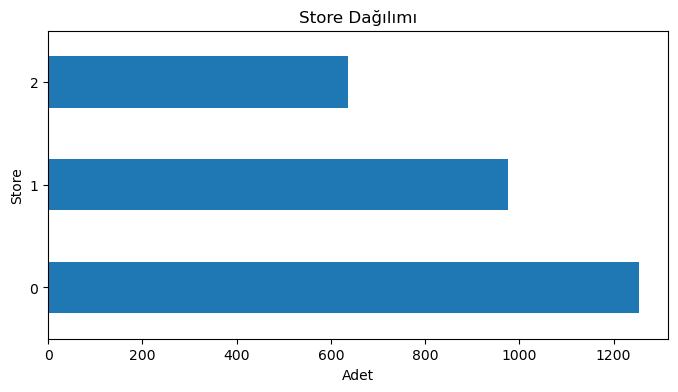

In [12]:
plt.figure(figsize=(8,4))
df['Origin'].value_counts().plot.barh()
plt.title('Store Dağılımı')
plt.xlabel('Adet')
plt.ylabel('Store')
plt.show()

# Amazon US - Prime
# CAL WH
# IL WH

In [13]:
sku_sales = df.groupby('Component SKU')['Total Demand'].sum().sort_values()


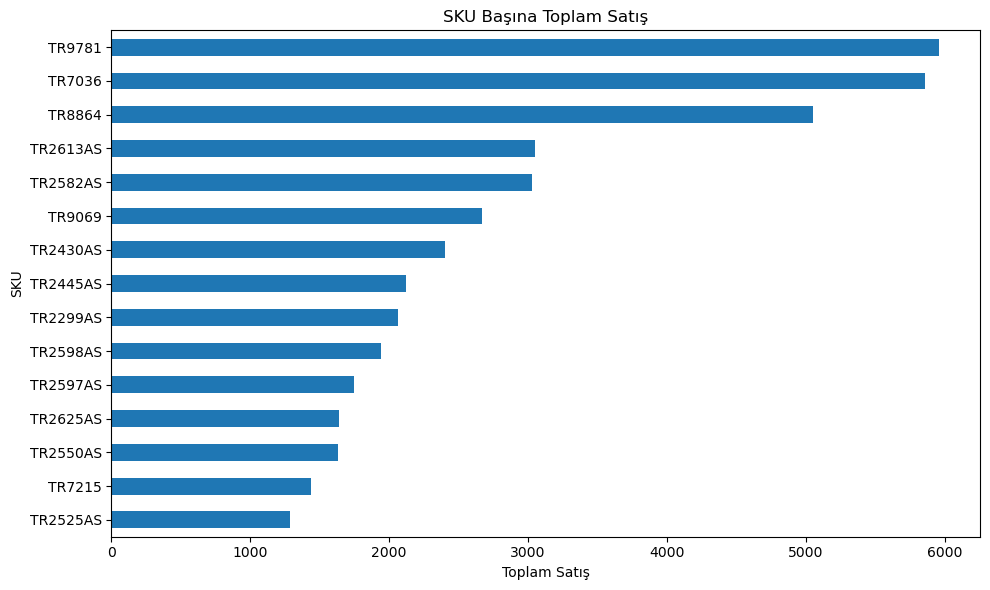

In [14]:
plt.figure(figsize=(10, 6))
sku_sales.plot(kind='barh')
plt.title('SKU Başına Toplam Satış') # Quantity
plt.xlabel('Toplam Satış')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

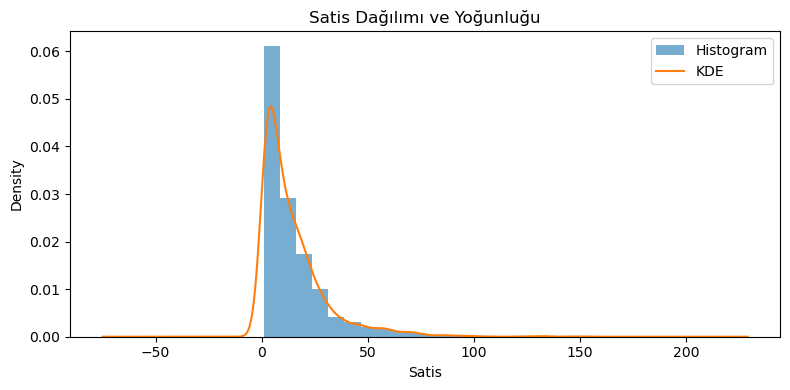

In [15]:
plt.figure(figsize=(8,4))
ax = df['Total Demand'].plot(kind='hist', bins=20, density=True, alpha=0.6, label='Histogram')
df['Total Demand'].plot(kind='kde', ax=ax, label='KDE')
plt.title('Satis Dağılımı ve Yoğunluğu')
plt.xlabel('Satis')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
import sys

# --- 1. Veri Yükleme ---
# Sizin belirttiğiniz dosya yolu:
file_path = '/Users/gametime/Downloads/Satis_verileri_guncel.csv'

try:
    df = pd.read_csv(file_path)
    print(f"'{file_path}' başarıyla yüklendi.")
    print(f"Veri Seti Boyutu (Satır, Sütun): {df.shape}")
    print(f"İlk 5 satır:\n{df.head()}\n")

except FileNotFoundError:
    print(f"HATA: Dosya bulunamadı.")
    print(f"Lütfen '{file_path}' yolunun doğru olduğundan emin olun.")
    sys.exit() # Dosya bulunamazsa kodu durdur
except Exception as e:
    print(f"Bir hata oluştu: {e}")
    sys.exit()


# --- 2. Sütun Belirleme ---
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# LÜTFEN BURAYI GÜNCELLEYİN:
# Aykırı değerleri arayacağınız sütunun adını tırnak içinde yazın.
INCELECEK_SUTUN_ADI = 'Total Demand'  # <-- Örnek olarak 'SatisAdeti' yazıldı. Kendi sütun adınızla değiştirin.
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Belirtilen sütunun veri setinde olup olmadığını kontrol edelim
if INCELECEK_SUTUN_ADI not in df.columns:
    print(f"HATA: '{INCELECEK_SUTUN_ADI}' sütunu veri setinizde bulunamadı.")
    print("Lütfen yukarıdaki değişkeni güncelleyin.")
    print(f"Mevcut Sütunlar: {df.columns.tolist()}")
else:
    # Sütun varsa, sayısal bir sütun mu diye kontrol edelim
    if not pd.api.types.is_numeric_dtype(df[INCELECEK_SUTUN_ADI]):
        print(f"UYARI: '{INCELECEK_SUTUN_ADI}' sütunu sayısal bir tipte değil (Mevcut tip: {df[INCELECEK_SUTUN_ADI].dtype}).")
        print("Doğru sonuçlar için bu sütunun sayısal (int, float) olması gerekir.")
    else:
        satis_verisi = df[INCELECEK_SUTUN_ADI].dropna() # NaN değerleri çıkar
        
        # --- Yöntem 1: IQR (Interquartile Range) ---
        # (Satış verileri için genellikle daha güvenilirdir)
        print(f"\n--- Yöntem 1: IQR ({INCELECEK_SUTUN_ADI} sütunu için) ---")
        
        Q1 = satis_verisi.quantile(0.25)
        Q3 = satis_verisi.quantile(0.75)
        IQR = Q3 - Q1
        
        alt_sinir = Q1 - 1.5 * IQR
        ust_sinir = Q3 + 1.5 * IQR
        
        print(f"Q1 (%25. Yüzdelik): {Q1:.2f}")
        print(f"Q3 (%75. Yüzdelik): {Q3:.2f}")
        print(f"IQR (Q3 - Q1): {IQR:.2f}")
        print(f"Alt Sınır (Q1 - 1.5*IQR): {alt_sinir:.2f}")
        print(f"Üst Sınır (Q3 + 1.5*IQR): {ust_sinir:.2f}")
        
        # Aykırı değerleri filtrele
        aykiri_degerler_iqr = df[(df[INCELECEK_SUTUN_ADI] < alt_sinir) | (df[INCELECEK_SUTUN_ADI] > ust_sinir)]
        
        print("\nIQR Yöntemi ile Tespit Edilen Aykırı Değerler:")
        if aykiri_degerler_iqr.empty:
            print("Aykırı değer bulunamadı.")
        else:
            print(f"Toplam {len(aykiri_degerler_iqr)} adet aykırı değer bulundu.")
            print(aykiri_degerler_iqr)

        # --- Yöntem 2: Z-Skoru (Standart Sapma) ---
        print(f"\n--- Yöntem 2: Z-Skoru ({INCELECEK_SUTUN_ADI} sütunu için) ---")
        
        ortalama = np.mean(satis_verisi)
        std_sapma = np.std(satis_verisi)
        esik_degeri = 3 # 3 standart sapma dışındakiler
        
        print(f"Ortalama: {ortalama:.2f}")
        print(f"Standart Sapma: {std_sapma:.2f}")
        print(f"Kullanılan Eşik Değeri: {esik_degeri} (Ortalamadan +/- {esik_degeri} standart sapma dışı)")

        # Z-Skorlarını hesapla
        df['Z_Skoru'] = (df[INCELECEK_SUTUN_ADI] - ortalama) / std_sapma
        
        # Aykırı değerleri filtrele
        aykiri_degerler_z = df[np.abs(df['Z_Skoru']) > esik_degeri]
        
        print(f"\nZ-Skoru Yöntemi ile Tespit Edilen Aykırı Değerler:")
        if aykiri_degerler_z.empty:
            print("Aykırı değer bulunamadı.")
        else:
            print(f"Toplam {len(aykiri_degerler_z)} adet aykırı değer bulundu.")
            # Z_Skoru sütunu sadece yardımcıydı, orijinal veriyi gösterelim
            print(aykiri_degerler_z.drop('Z_Skoru', axis=1))

            # --- 4. Değiştirme İşlemi (Alternatif: Clipping) ---
        print(f"\n--- Alternatif Yöntem: Clipping (Kırpma) ---")
        yeni_sutun_adi_clip = f"{INCELECEK_SUTUN_ADI}_temiz_clip"

        df[yeni_sutun_adi_clip] = df[INCELECEK_SUTUN_ADI].clip(lower=alt_sinir, upper=ust_sinir)

        print(f"'{yeni_sutun_adi_clip}' sütunu oluşturuldu.")
        print(f"Değerler {alt_sinir:.2f} ve {ust_sinir:.2f} aralığına kırpıldı.")

# --- 5. Sonucu Kontrol Etme ---
        print("\nClipping Sonrası Sütun İstatistikleri:")
        print(df[yeni_sutun_adi_clip].describe())

'/Users/gametime/Downloads/Satis_verileri_guncel.csv' başarıyla yüklendi.
Veri Seti Boyutu (Satır, Sütun): (2866, 14)
İlk 5 satır:
   Origin  Year  Week Component SKU  Total Demand Average Selling Price  \
0       0  2024     1      TR2299AS            15               $249.99   
1       0  2024     1      TR2430AS             9               $249.99   
2       0  2024     1      TR2445AS            26               $169.99   
3       0  2024     1      TR2525AS             6               $279.99   
4       0  2024     1      TR2550AS             9               $219.99   

   IsHoliday  IsPromotion      COG  Profit Rate  Average Rating  \
0          1            0  $112.92           25             4.4   
1          1            0   $98.96           22             4.3   
2          1            0   $98.96           25             4.4   
3          1            0  $125.50           15             4.2   
4          1            0  $130.48            7             4.2   

   Product Cate

In [5]:
import pandas as pd
import numpy as np
import sys

# --- 1. Veri Yükleme ---
file_path = '/Users/gametime/Downloads/Satis_verileri_guncel.csv'
try:
    df = pd.read_csv(file_path)
except Exception as e:
    print(f"HATA: Dosya yüklenirken bir sorun oluştu: {e}")
    sys.exit()

# --- 2. Sütun Belirleme ---
INCELECEK_SUTUN_ADI = 'Total Demand'  # <-- Kendi sütun adınızla değiştirin

if INCELECEK_SUTUN_ADI not in df.columns:
    print(f"HATA: '{INCELECEK_SUTUN_ADI}' sütunu bulunamadı.")
    sys.exit()

print(f"'{INCELECEK_SUTUN_ADI}' sütunu üzerinde çalışılıyor...\n")
    
# --- 3. Orijinal Sınırları Hesaplama (Clipping için kullanılan) ---
# Sadece orijinal sütundaki NaN olmayan değerleri al
satis_verisi_orijinal = df[INCELECEK_SUTUN_ADI].dropna() 

Q1_orijinal = satis_verisi_orijinal.quantile(0.25)
Q3_orijinal = satis_verisi_orijinal.quantile(0.75)
IQR_orijinal = Q3_orijinal - Q1_orijinal

alt_sinir_orijinal = Q1_orijinal - 1.5 * IQR_orijinal
ust_sinir_orijinal = Q3_orijinal + 1.5 * IQR_orijinal

print(f"--- Kontrol Adımı ---")
print(f"Clipping için kullanılan ORİJİNAL sınırlar:")
print(f"Orijinal Alt Sınır: {alt_sinir_orijinal:.2f}")
print(f"Orijinal Üst Sınır: {ust_sinir_orijinal:.2f}\n")

# --- 4. Clipping İşlemini Uygula ---
yeni_sutun_adi_clip = f"{INCELECEK_SUTUN_ADI}_temiz_clip"

# Orijinal sütunu al, NaN değerleri koruyarak clip yap
df[yeni_sutun_adi_clip] = df[INCELECEK_SUTUN_ADI].clip(lower=alt_sinir_orijinal, upper=ust_sinir_orijinal)

print(f"'{yeni_sutun_adi_clip}' sütunu oluşturuldu/güncellendi.\n")


# --- 5. YENİ Sütunu KONTROL ETME ---
# Şimdi, 'temizlenmiş' sütundaki değerleri, 'orijinal' sınırlar ile karşılaştır.
temizlenmis_sutun = df[yeni_sutun_adi_clip]

# Orijinal sınırlara göre aykırı değer ara
# Not: Burada < ve > kullanıyoruz (<= veya >= değil)
kalan_aykiri_degerler = df[
    (temizlenmis_sutun < alt_sinir_orijinal) | 
    (temizlenmis_sutun > ust_sinir_orijinal)
]

print(f"--- '{yeni_sutun_adi_clip}' Sütunu Üzerinde Aykırı Değer Kontrolü ---")
if kalan_aykiri_degerler.empty:
    print(f"SONUÇ: Başarılı. '{yeni_sutun_adi_clip}' sütununda artık aykırı değer bulunmuyor.")
    print("Tüm değerler orijinal sınırlar dahilinde.")
else:
    # Bu durumun teorik olarak yaşanmaması gerekir
    print(f"HATA: Beklenmedik bir durum. Halen {len(kalan_aykiri_degerler)} adet aykırı değer bulundu:")
    print(kalan_aykiri_degerler)

# --- Ekstra Doğrulama: Yeni Sütunun Min/Max Değerleri ---
# (NaN değerleri hesaba katmamak için .dropna() ekledik)
min_deger_yeni = temizlenmis_sutun.dropna().min()
max_deger_yeni = temizlenmis_sutun.dropna().max()

print("\n--- Ekstra Doğrulama (Min/Max) ---")
print(f"Yeni sütunun ('{yeni_sutun_adi_clip}') minimum değeri: {min_deger_yeni:.2f}")
print(f"Yeni sütunun ('{yeni_sutun_adi_clip}') maksimum değeri: {max_deger_yeni:.2f}")

# assert (iddia) kullanarak programatik kontrol
assert min_deger_yeni >= alt_sinir_orijinal, "Hata: Min değer alt sınırdan küçük!"
assert max_deger_yeni <= ust_sinir_orijinal, "Hata: Max değer üst sınırdan büyük!"

print("\nDoğrulama başarılı: Yeni min/max değerleri orijinal sınırlar içinde.")

'Total Demand' sütunu üzerinde çalışılıyor...

--- Kontrol Adımı ---
Clipping için kullanılan ORİJİNAL sınırlar:
Orijinal Alt Sınır: -18.50
Orijinal Üst Sınır: 41.50

'Total Demand_temiz_clip' sütunu oluşturuldu/güncellendi.

--- 'Total Demand_temiz_clip' Sütunu Üzerinde Aykırı Değer Kontrolü ---
SONUÇ: Başarılı. 'Total Demand_temiz_clip' sütununda artık aykırı değer bulunmuyor.
Tüm değerler orijinal sınırlar dahilinde.

--- Ekstra Doğrulama (Min/Max) ---
Yeni sütunun ('Total Demand_temiz_clip') minimum değeri: 1.00
Yeni sütunun ('Total Demand_temiz_clip') maksimum değeri: 41.50

Doğrulama başarılı: Yeni min/max değerleri orijinal sınırlar içinde.


In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


In [7]:
df['Total Demand'] = pd.to_numeric(df['Total Demand'], errors='coerce')  # Satış verisini sayıya çeviriyoruz (gerekirse)
grouped = df.groupby(['Component SKU', 'Year', 'Week'], as_index=False)['Total Demand'].sum()

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import pickle
import sys
import warnings

# Uyarıları bastır
warnings.filterwarnings('ignore')

# --- 1. VERİ YÜKLEME ---
FILE_PATH = '/Users/gametime/Downloads/Satis_verileri_guncel.csv'

try:
    df = pd.read_csv(FILE_PATH)
    print(f"'{FILE_PATH}' başarıyla yüklendi.")
    print(f"Veri Seti Boyutu (Satır, Sütun): {df.shape}\n")
except Exception as e:
    print(f"HATA: Dosya yüklenemedi: {e}")
    sys.exit()

# --- 2. HEDEF SÜTUNU VE VERİ TİPİ DÖNÜŞÜMÜ ---
HEDEF_SUTUN = 'Total Demand' 

if HEDEF_SUTUN not in df.columns:
    print(f"HATA: '{HEDEF_SUTUN}' hedef sütunu veri setinizde bulunamadı.")
    sys.exit()

print(f"Model, '{HEDEF_SUTUN}' sütununu hedef olarak kullanacak.")

print("Veri tipi dönüşümü başlatılıyor (örn: $ karakterleri temizleniyor)...")
KNOWN_OBJECT_COLS = ['Component SKU', 'Origin'] 
for col in df.columns:
    if col not in KNOWN_OBJECT_COLS and col != HEDEF_SUTUN and df[col].dtype == 'object':
        print(f"'{col}' sütunu temizlenip 'float' tipine dönüştürülüyor...")
        try:
            df[col] = df[col].astype(str).str.replace(r'[$,]', '', regex=True)
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except Exception as e:
            print(f"UYARI: '{col}' sütunu dönüştürülürken hata oluştu: {e}")
print("Veri tipi dönüşümü tamamlandı.\n")


# ==============================================================================
# ### YENİ ADIM: 3. 'ORIGIN' BAZINDA TOPLULAŞTIRMA (AGGREGATION) ###
# ==============================================================================
print("Veri 'Origin' bazında toplanıyor...")
print(f"Agregasyon öncesi satır sayısı: {len(df)}")

# Agregasyon için gruplama anahtarları
group_keys = ['Year', 'Week', 'Component SKU']

# Agregasyon kuralları
agg_dict = {
    'Total Demand': 'sum'  # Ana hedefi TOPLA
}

# Kalan sütunları (anahtarlar ve 'Origin' hariç) dinamik olarak belirle
other_cols = [col for col in df.columns if col not in group_keys + ['Total Demand', 'Origin']]

for col in other_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        # Price, Ad Spend gibi sayısal özellikler için ORTALAMA al
        agg_dict[col] = 'mean'
    else:
        # Diğer (örn: 'WeekNum') için İLK değeri al
        agg_dict[col] = 'first' 

# Gruplama işlemini yap
df = df.groupby(group_keys, as_index=False).agg(agg_dict)

print(f"Agregasyon sonrası yeni satır sayısı: {len(df)}")
print("'Origin' sütunu kaldırıldı, Total Demand toplandı.\n")
# ==============================================================================


# --- 4. EĞİTİM VERİ SETİNİ TANIMLAMA ---
TRAINING_END_WEEK = 38
TRAINING_END_YEAR = 2025
# 2024 ve 2025 verisinin tamamını al (yeni 'df' üzerinden)
training_df = df[
    (df['Year'] < TRAINING_END_YEAR) | 
    ((df['Year'] == TRAINING_END_YEAR) & (df['Week'] <= TRAINING_END_WEEK))
].copy()

# Ağırlıklandırma
weight_2025 = 2.0  
weight_2024 = 1.0  
training_df['sample_weight'] = np.where(training_df['Year'] == 2025, weight_2025, weight_2024)
print("Ağırlıklandırma eklendi: 2025 verisi (2.0x), 2024 verisi (1.0x).")


# --- 5. HİPERPARAMETRE OPTİMİZASYONU İÇİN HAZIRLIK ---
param_grid = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'subsample': [0.9, 1.0]
}
best_models = {}
all_mae_scores = {} 


# --- 6. SKU BAZLI MODEL EĞİTİM DÖNGÜSÜ ---
print("\n===== SKU Bazlı Eğitim Döngüsü Başlıyor =====")

for sku, grp in training_df.groupby("Component SKU"):
    print(f"--- {sku} için model eğitimi başlıyor... ---")
    sku_df = grp.sort_values(['Year', 'Week']).copy()

    if len(sku_df) < 20: 
        print(f"'{sku}' için yeterli veri yok (Minimum ~20 hafta gerekli), atlanıyor.")
        continue

    # 6.1. SKU-Bazlı Özellik Mühendisliği
    sku_df['Date'] = pd.to_datetime(sku_df['Year'].astype(str) + sku_df['Week'].astype(str).str.zfill(2) + '1', format='%Y%W%w', errors='coerce')
    sku_df['Month'] = sku_df['Date'].dt.month
    
    sku_df['lag1'] = sku_df[HEDEF_SUTUN].shift(1)
    sku_df['lag2'] = sku_df[HEDEF_SUTUN].shift(2)
    sku_df['lag52'] = sku_df[HEDEF_SUTUN].shift(52)
    
    sku_df.drop(columns=['Date'], inplace=True)
    
    # Hibrit Yöntem (lag52 için)
    sku_df['has_lag52'] = sku_df['lag52'].notnull().astype(int)
    sku_df['lag52'] = sku_df['lag52'].fillna(0)
    sku_df.dropna(subset=['lag1', 'lag2'], inplace=True) 
    
    print(f"'{sku}' için lag oluşturuldu, {len(sku_df)} satır (2024+2025) eğitime hazır.")

    if sku_df.empty or len(sku_df) < 15: 
        print(f"'{sku}' için lag oluşturduktan sonra yeterli veri kalmadı, atlanıyor.")
        continue

    # 6.2. Veri Hazırlığı
    # DÜZELTME: 'Origin' artık bir sütun değil, kategorik listeden kaldırıldı.
    categorical_cols = [col for col in ['WeekNum', 'Month'] if col in sku_df.columns]
    
    if categorical_cols:
        processed_sku_df = pd.get_dummies(sku_df, columns=categorical_cols, drop_first=True)
    else:
        processed_sku_df = sku_df.copy()
    
    # 'has_lag52' artık bir özellik (feature)
    feats = [c for c in processed_sku_df.columns if c not in [HEDEF_SUTUN, 'Component SKU', 'Week', 'sample_weight', 'Year']]
    
    X = processed_sku_df[feats]
    y = processed_sku_df[HEDEF_SUTUN]
    
    sample_weights = processed_sku_df.loc[X.index, 'sample_weight']

    if len(X) < 15: 
        print(f"'{sku}' için eğitim verisi yetersiz (son < 15), atlanıyor.")
        continue

    # 6.3. Model Optimizasyonu
    tscv = TimeSeriesSplit(n_splits=3)
    random_search = RandomizedSearchCV(
        estimator=GradientBoostingRegressor(random_state=42),
        param_distributions=param_grid,
        n_iter=60, 
        cv=tscv, 
        scoring='neg_mean_absolute_error',
        n_jobs=-1, 
        random_state=42
    )
    
    random_search.fit(X, y, sample_weight=sample_weights)

    # 6.4. En İyi Modeli Kaydet
    best_model = random_search.best_estimator_
    best_models[sku] = best_model
    
    validation_mae_cv = -random_search.best_score_
    
    # --- 2024 vs 2025 MAE HESAPLAMASI ---
    mask_2024 = (processed_sku_df['Year'] == 2024)
    mask_2025 = (processed_sku_df['Year'] == 2025)

    X_2024, y_2024 = X.loc[mask_2024], y.loc[mask_2024]
    X_2025, y_2025 = X.loc[mask_2025], y.loc[mask_2025]

    mae_2024_train = np.nan
    mae_2025_train = np.nan

    if not X_2024.empty:
        preds_2024 = best_model.predict(X_2024)
        mae_2024_train = mean_absolute_error(y_2024, preds_2024)

    if not X_2025.empty:
        preds_2025 = best_model.predict(X_2025)
        mae_2025_train = mean_absolute_error(y_2025, preds_2025)

    all_mae_scores[sku] = {
        'MAE_Validation_CV': round(validation_mae_cv, 2),
        'MAE_2024_Egitim': round(mae_2024_train, 2) if not np.isnan(mae_2024_train) else None,
        'MAE_2025_Egitim': round(mae_2025_train, 2) if not np.isnan(mae_2025_train) else None
    }
    
    print(f"'{sku}' için eğitim tamamlandı.")
    print(f"   CV Validasyon MAE (Genel): {validation_mae_cv:.2f}")
    if not np.isnan(mae_2024_train):
        print(f"   2024 (Eğitim Verisi) MAE: {mae_2024_train:.2f}")
    if not np.isnan(mae_2025_train):
        print(f"   2025 (Eğitim Verisi) MAE: {mae_2025_train:.2f}")

# --- 7. KAYIT İŞLEMLERİ ---
with open('best_models.pkl', 'wb') as f:
    pickle.dump(best_models, f)

with open('all_mae_scores.pkl', 'wb') as f:
    pickle.dump(all_mae_scores, f)

print("\n===== Eğitim Süreci Başarıyla Tamamlandı! =====")
print("Modeller 'best_models.pkl' dosyasına kaydedildi.")
print("Detaylı (2024, 2025, CV) MAE değerleri 'all_mae_scores.pkl' dosyasına kaydedildi.")

'/Users/gametime/Downloads/Satis_verileri_guncel.csv' başarıyla yüklendi.
Veri Seti Boyutu (Satır, Sütun): (2866, 14)

Model, 'Total Demand' sütununu hedef olarak kullanacak.
Veri tipi dönüşümü başlatılıyor (örn: $ karakterleri temizleniyor)...
'Average Selling Price' sütunu temizlenip 'float' tipine dönüştürülüyor...
'COG' sütunu temizlenip 'float' tipine dönüştürülüyor...
'Advertising Spend' sütunu temizlenip 'float' tipine dönüştürülüyor...
'Competitor Price Index' sütunu temizlenip 'float' tipine dönüştürülüyor...
Veri tipi dönüşümü tamamlandı.

Veri 'Origin' bazında toplanıyor...
Agregasyon öncesi satır sayısı: 2866
Agregasyon sonrası yeni satır sayısı: 1364
'Origin' sütunu kaldırıldı, Total Demand toplandı.

Ağırlıklandırma eklendi: 2025 verisi (2.0x), 2024 verisi (1.0x).

===== SKU Bazlı Eğitim Döngüsü Başlıyor =====
--- TR2299AS için model eğitimi başlıyor... ---
'TR2299AS' için lag oluşturuldu, 89 satır (2024+2025) eğitime hazır.
'TR2299AS' için eğitim tamamlandı.
   CV Valida

In [24]:
import pandas as pd
import numpy as np
import pickle
import sys
import warnings

# Uyarıları bastır
warnings.filterwarnings('ignore')

# --- 0. TANIMLAMALAR ---
HEDEF_SUTUN = 'Total Demand'
FILE_PATH = '/Users/gametime/Downloads/Satis_verileri_guncel.csv'


# --- 1. MODELLERİ, MAE DEĞERLERİNİ VE ANA VERİYİ YÜKLEME ---
try:
    print("Modeller 'best_models.pkl' dosyasından yükleniyor...")
    with open('best_models.pkl', 'rb') as f:
        best_models = pickle.load(f)
    
    print("MAE skorları 'all_mae_scores.pkl' dosyasından yükleniyor...")
    with open('all_mae_scores.pkl', 'rb') as f:
        all_mae_scores = pickle.load(f)
        
    print(f"Ana veri seti '{FILE_PATH}' dosyasından yükleniyor...")
    df_raw = pd.read_csv(FILE_PATH)
    
    # --- Veri Tipi Dönüşümü (Eğitimdekiyle Aynı) ---
    print("Veri tipi dönüşümü başlatılıyor (örn: $ karakterleri temizleniyor)...")
    KNOWN_OBJECT_COLS = ['Component SKU', 'Origin'] 
    for col in df_raw.columns:
        if col not in KNOWN_OBJECT_COLS and col != HEDEF_SUTUN and df_raw[col].dtype == 'object':
            print(f"'{col}' sütunu temizlenip 'float' tipine dönüştürülüyor...")
            try:
                df_raw[col] = df_raw[col].astype(str).str.replace(r'[$,]', '', regex=True)
                df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
            except Exception as e:
                print(f"UYARI: '{col}' sütunu dönüştürülürken hata oluştu: {e}")
    print("Veri tipi dönüşümü tamamlandı.")
    
    # --- YENİ EĞİTİM ADIMI: Origin Bazında Toplulaştırma (Eğitimdekiyle Aynı) ---
    print("Veri 'Origin' bazında toplanıyor...")
    print(f"Agregasyon öncesi satır sayısı: {len(df_raw)}")
    group_keys = ['Year', 'Week', 'Component SKU']
    agg_dict = {'Total Demand': 'sum'}
    other_cols = [col for col in df_raw.columns if col not in group_keys + ['Total Demand', 'Origin']]
    for col in other_cols:
        if pd.api.types.is_numeric_dtype(df_raw[col]):
            agg_dict[col] = 'mean'
        else:
            agg_dict[col] = 'first' 
    df = df_raw.groupby(group_keys, as_index=False).agg(agg_dict)
    print(f"Agregasyon sonrası yeni satır sayısı: {len(df)}\n")
    # --- Toplulaştırma Sonu ---
    
    print("Tüm dosyalar başarıyla yüklendi.\n")

except FileNotFoundError as e:
    print(f"HATA: Gerekli dosya bulunamadı: {e.filename}")
    sys.exit()
except Exception as e:
    print(f"Bir hata oluştu: {e}")
    sys.exit()


# --- 2. TAHMİN PARAMETRELERİNİ TANIMLAMA ---
PREDICTION_START_YEAR = 2025
PREDICTION_START_WEEK = 39
PREDICTION_END_WEEK = 52

all_predictions_df = pd.DataFrame() 
print(f"Tahmin periyodu: {PREDICTION_START_YEAR}, Hafta {PREDICTION_START_WEEK} - {PREDICTION_END_WEEK}")

# --- 3. SKU BAZLI TAHMİN ÜRETİM DÖNGÜSÜ ---
for sku, model in best_models.items():
    print(f"\n===== {sku} için tahmin süreci başlatılıyor... =====")

    # 3.1. Geçmiş Veriyi ve Gelecek Şablonunu Hazırlama
    history_df = df[
        (df['Component SKU'] == sku) & 
        ((df['Year'] < PREDICTION_START_YEAR) | 
        ((df['Year'] == PREDICTION_START_YEAR) & (df['Week'] < PREDICTION_START_WEEK)))
    ].sort_values(['Year', 'Week']).copy()

    if history_df.empty:
        print(f"{sku} için yeterli geçmiş veri bulunamadı, atlanıyor.")
        continue

    last_known_data = history_df.iloc[-1].copy()
    future_template_df = pd.DataFrame([last_known_data] * len(future_weeks_range))

    # Gelecek haftalar için şablonu hazırla
    last_known_data = history_df.iloc[-1].copy()
    future_weeks_range = range(PREDICTION_START_WEEK, PREDICTION_END_WEEK + 1)
    future_template_df = pd.DataFrame([last_known_data] * len(future_weeks_range))
    future_template_df['Year'] = PREDICTION_START_YEAR
    future_template_df['Week'] = list(future_weeks_range)
    if 'WeekNum' in future_template_df.columns:
        future_template_df['WeekNum'] = list(future_weeks_range)
    
    # 3.3. İteratif Tahmin Döngüsü
    training_columns = model.feature_names_in_
    predictions_list = []
    iterative_history = history_df.copy()
    
    sku_scores = all_mae_scores.get(sku, {})
    # Hata payı için 2025 (güncel) MAE'yi veya CV MAE'yi kullanabilirsiniz.
    mae = sku_scores.get('MAE_2025_Egitim', 0) 
    if mae is None: 
        mae = 0
    
    print(f"{sku} için MAE (hata payı): {mae:.2f}")

    for week in sorted(future_template_df['Week'].unique()):
        next_week_known_features = future_template_df[future_template_df['Week'] == week].copy()
        next_week_known_features[HEDEF_SUTUN] = np.nan 
        
        combined_df = pd.concat([iterative_history, next_week_known_features], ignore_index=True)
        
        # Eğitim koduyla birebir aynı hibrit özellik mühendisliği
        combined_df['Date'] = pd.to_datetime(combined_df['Year'].astype(str) + combined_df['Week'].astype(str).str.zfill(2) + '1', format='%Y%W%w', errors='coerce')
        combined_df['Month'] = combined_df['Date'].dt.month
        combined_df['lag1'] = combined_df[HEDEF_SUTUN].shift(1)
        combined_df['lag2'] = combined_df[HEDEF_SUTUN].shift(2)
        combined_df['lag52'] = combined_df[HEDEF_SUTUN].shift(52)
        combined_df.drop(columns=['Date'], inplace=True)
        
        combined_df['has_lag52'] = combined_df['lag52'].notnull().astype(int)
        combined_df['lag52'] = combined_df['lag52'].fillna(0)
        combined_df[['lag1', 'lag2']] = combined_df[['lag1', 'lag2']].ffill()
        combined_df.fillna(0, inplace=True) 
        
        # Kategorik özellikleri işle (Origin artık yok)
        categorical_cols = [col for col in ['WeekNum', 'Month'] if col in combined_df.columns]
        if categorical_cols:
            processed_df = pd.get_dummies(combined_df, columns=categorical_cols, drop_first=True)
        else:
            processed_df = combined_df.copy()
        
        X_future_raw = processed_df.tail(1)
        X_future_aligned = X_future_raw.reindex(columns=training_columns, fill_value=0)
        
        prediction = model.predict(X_future_aligned)[0]
        
        # Stokastik Geri Besleme (Eğitimli Gürültü)
        if mae > 0:
            noise = np.random.normal(0, mae / 2) 
            prediction += noise
        
        prediction = max(0, round(prediction))
        
        # --- YENİ ADIM 1: Haftalık Aralığı Hesapla ---
        lower_bound_w = max(0, round(prediction - mae))
        upper_bound_w = round(prediction + mae)
        

        predictions_list.append({
            'SKU': sku, 
            'Year': PREDICTION_START_YEAR, 
            'Week': week, 
            'Prediction': prediction,
            'Lower_Bound_Weekly': lower_bound_w,  # YENİ SÜTUN
            'Upper_Bound_Weekly': upper_bound_w   # YENİ SÜTUN
        })
        
        # Tahmini, geçmiş veriye ekle
        new_row_to_add = next_week_known_features.copy()
        new_row_to_add[HEDEF_SUTUN] = prediction
        iterative_history = pd.concat([iterative_history, new_row_to_add], ignore_index=True)

    # 3.4. Sonuçları Formatlama ve Yazdırma
    sku_predictions_df = pd.DataFrame(predictions_list)
    
    if not sku_predictions_df.empty:
        all_predictions_df = pd.concat([all_predictions_df, sku_predictions_df], ignore_index=True)

        # --- YENİ ADIM 2: Haftalık Çıktıyı Güncelle ---
        print(f"{sku} için haftalık tahminler (2025, W{PREDICTION_START_WEEK}-W{PREDICTION_END_WEEK}):")
        for _, row in sku_predictions_df.iterrows():
            print(f"  Week {int(row['Week'])}: Tahmin: {int(row['Prediction'])} | Güven Aralığı: ({int(row['Lower_Bound_Weekly'])} - {int(row['Upper_Bound_Weekly'])})")
        # --- BİTTİ ---
        
        # Aylık Özet
        sku_predictions_df['Date'] = pd.to_datetime(sku_predictions_df['Year'].astype(str) + sku_predictions_df['Week'].astype(str).str.zfill(2) + '1', format='%Y%W%w', errors='coerce')
        sku_predictions_df['MonthNum'] = sku_predictions_df['Date'].dt.month
        month_map = {10: 'Ekim', 11: 'Kasım', 12: 'Aralık'} 
        sku_predictions_df['MonthName'] = sku_predictions_df['MonthNum'].map(month_map)
        
        # --- YENİ ADIM 3: Aylık Özeti İyileştir (Haftalıkları Topla) ---
        monthly_summary = sku_predictions_df.groupby(['MonthNum', 'MonthName']).agg(
            Total_Prediction=('Prediction', 'sum'),
            Lower_Bound=('Lower_Bound_Weekly', 'sum'), # Haftalık alt limitleri topla
            Upper_Bound=('Upper_Bound_Weekly', 'sum')  # Haftalık üst limitleri topla
        ).reset_index().sort_values('MonthNum')
        
        # Formüle dayalı 'Monthly_Error' hesaplaması kaldırıldı, artık gerek yok.

        print(f"\n  {sku} için AYLIK TAHMİN ÖZETİ (Güven Aralıklı):")
        for _, row in monthly_summary.iterrows():
            print(f"    - {row['MonthName']}: Tahmin: {int(row['Total_Prediction'])} | Güven Aralığı: ({row['Lower_Bound']} - {row['Upper_Bound']})")
        # --- BİTTİ ---
    
    else:
        print(f"{sku} için tahmin üretilemedi.")

# --- 4. TÜM TAHMİNLERİ KAYDETME ---
if not all_predictions_df.empty:
    output_filename = 'tum_sku_tahminleri_2025_Q4.csv'
    # Yeni 'Lower_Bound_Weekly' ve 'Upper_Bound_Weekly' sütunları da kaydedilecek
    all_predictions_df.to_csv(output_filename, index=False)
    print(f"\n===== Tahmin Süreci Tamamlandı! =====")
    print(f"Tüm SKU'lar için tahminler (haftalık aralıklar dahil) '{output_filename}' dosyasına kaydedildi.")
else:
    print("\n===== Tahmin Süreci Tamamlandı! =====")
    print("Hiçbir SKU için tahmin üretilemedi.")

Modeller 'best_models.pkl' dosyasından yükleniyor...
MAE skorları 'all_mae_scores.pkl' dosyasından yükleniyor...
Ana veri seti '/Users/gametime/Downloads/Satis_verileri_guncel.csv' dosyasından yükleniyor...
Veri tipi dönüşümü başlatılıyor (örn: $ karakterleri temizleniyor)...
'Average Selling Price' sütunu temizlenip 'float' tipine dönüştürülüyor...
'COG' sütunu temizlenip 'float' tipine dönüştürülüyor...
'Advertising Spend' sütunu temizlenip 'float' tipine dönüştürülüyor...
'Competitor Price Index' sütunu temizlenip 'float' tipine dönüştürülüyor...
Veri tipi dönüşümü tamamlandı.
Veri 'Origin' bazında toplanıyor...
Agregasyon öncesi satır sayısı: 2866
Agregasyon sonrası yeni satır sayısı: 1364

Tüm dosyalar başarıyla yüklendi.

Tahmin periyodu: 2025, Hafta 39 - 52

===== TR2299AS için tahmin süreci başlatılıyor... =====
TR2299AS için MAE (hata payı): 4.38
TR2299AS için haftalık tahminler (2025, W39-W52):
  Week 39: Tahmin: 22 | Güven Aralığı: (18 - 26)
  Week 40: Tahmin: 20 | Güven Ara